In [1]:
import argparse
import pathlib
from pathlib import Path
import time
from datetime import timedelta
import json
import os
import pandas as pd
import numpy as np
import itertools
import csv
import anndata
import javabridge
# silence copious tensorflow warnings
import tensorflow as tf
#tf.get_logger().setLevel("ERROR")
import pathml
from pathml.core import CODEXSlide
from pathml.core import SlideData
from scipy.spatial.distance import cdist
from pathml.preprocessing import Pipeline, CollapseRunsCODEX, SegmentMIF, QuantifyMIF

2023-02-22 21:23:38.475003: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-02-22 21:23:38.475390: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
print(f"working dir: {os.getcwd()}")

working dir: /n/data2/dfci/cancerimm/wucherpfennig/bhawesh


In [3]:
# Data Directory

os.chdir("/n/data2/dfci/cancerimm/wucherpfennig/bhawesh/projects/CODEX/test_p02")

In [4]:
metadata_p = Path("experiment_edited.json")

In [5]:
! ls

experiment_edited.json
p02_bl_cropped_20220516_Exp030_P02_BL_anndata.h5ad
p02_bl_cropped_20220516_Exp030_P02_BL_anndata.h5seurat
p02_bl_cropped_20220516_Exp030_P02_BL.h5path
p02_bl_cropped_20220516_Exp030_P02_BL_h5path_channel_order.txt
stitched.pattern
symlink
symlink_edited


In [6]:
with open(metadata_p) as f:
            experiment_metadata = json.load(f)
            channel_names = experiment_metadata["channelNames"]["channelNamesArray"]
            experiment_name = experiment_metadata["name"]

In [7]:
newlist = []
for i, v in enumerate(channel_names):
    totalcount = channel_names.count(v)
    count = channel_names[:i].count(v)
    newlist.append(v + "-" + str(count + 1) if totalcount > 1 else v)
channel_names = newlist

In [8]:
wsi_path = 'p02_bl_cropped_20220516_Exp030_P02_BL.h5path'
channels_path =  'p02_bl_cropped_20220516_Exp030_P02_BL_h5path_channel_order.txt'

In [9]:
wsi = SlideData(str(wsi_path))

/n/data2/dfci/cancerimm/wucherpfennig/tools/conda_codex_lab/lib/python3.8/site-packages/anndata/_io/h5ad.py:64: FutureWarning: The `force_dense` argument is deprecated. Use `as_dense` instead.
  warn(


In [10]:
channels = pd.read_csv(channels_path, sep = "\t", header = None)
channel_names = list(channels[1].values)

print("loaded channels:", channel_names, "\n")

loaded channels: ['Blank-1', 'Blank-2', 'Blank-3', 'Clec2d', 'PD-L1', 'CD45-RO', 'N-Cadherin', 'TCF7', 'CD3e', 'CD163', 'CD103', 'CXCR5', 'FAP', 'E-Cadherin', 'cl-Caspase3', 'PD-1', 'GZMB-D6E9W', 'CD1c', 'DAPI-09', 'CXCL13', 'CA9', 'FOXP3', 'CD56', 'CD31', 'GZMK', 'SLUG', 'Podoplanin', 'CD66b', 'Ki67', 'CD4', 'MHC1', 'CD25', 'DC-LAMP', 'Pancytokeratin', 'CD8', 'CD68', 'CD20', 'HLA-DR', 'Vimentin', 'Blank-4', 'Blank-5', 'Blank-6'] 



In [11]:
# 'CD3e', 'CD4', 'CD8', 'CD68', 'CD20', 'CD31', 'Pancytokeratin'

In [11]:
wsi.tiles.keys

['(0, 0)',
 '(0, 1848)',
 '(0, 3696)',
 '(1848, 0)',
 '(1848, 1848)',
 '(1848, 3696)',
 '(3696, 0)',
 '(3696, 1848)',
 '(3696, 3696)']

In [12]:
tile = wsi.tiles[(1848, 1848)]
tile.masks.keys()

dict_keys(['cell_segmentation', 'nuclear_segmentation'])

In [13]:
mask = tile.masks["nuclear_segmentation"].astype(int).squeeze()

In [14]:
mask.shape, len(np.unique(mask))

((2048, 2048), 2383)

In [16]:
# Convert to float and remove nans due to overflow by the max of the array
# If na
tile.image = tile.image.astype(np.float64)
global_max = np.nanmax(tile.image[tile.image != np.inf])
print(global_max)
tile.image[tile.image>global_max] = global_max

65504.0


In [17]:
# Raise assertion error if there are nans in the image
assert not np.isnan(tile.image).any(), "There are NaN values in the array"

In [18]:
os.chdir("/n/data2/dfci/cancerimm/wucherpfennig/bhawesh/code")

In [19]:
import cvmask

In [20]:
from transforms import FilterEdgeCells, MembraneMarkerWatershed, REDSEAQuantifyMIF, CheckNACounts
from transforms_cellseg_test import FilterEdgeCells,MembraneMarkerWatershed,CheckNACounts,CellSegQuantifyMIF
from scipy.spatial.distance import cdist

In [64]:
# Credits: https://github.com/michaellee1/CellSeg/blob/67e85001e7b8f62f844e03779079ab843eddd94e/src/cvmask.py

def compute_centroids(masks):
        
        num_masks = len(np.unique(masks)) - 1
        indices = np.where(masks != 0)
        values = masks[indices[0], indices[1]]

        maskframe = pd.DataFrame(np.transpose(np.array([indices[0], indices[1], values]))).rename(columns = {0:"x", 1:"y", 2:"id"})
        centroids = maskframe.groupby('id').agg({'x': 'mean', 'y': 'mean'}).to_numpy()
        
        return centroids

def remove_overlaps_nearest_neighbors(masks, centroids):
        final_masks = np.max(masks, axis = 2)
       
        collisions = np.nonzero(np.sum(masks > 0, axis = 2) > 1)
        collision_masks = masks[collisions]
        collision_index = np.nonzero(collision_masks)
        collision_masks = collision_masks[collision_index]
        collision_frame = pd.DataFrame(np.transpose(np.array([collision_index[0], collision_masks]))).rename(columns = {0:"collis_idx", 1:"mask_id"})
        grouped_frame = collision_frame.groupby('collis_idx')
        for collis_idx, group in grouped_frame:
            collis_pos = np.expand_dims(np.array([collisions[0][collis_idx], collisions[1][collis_idx]]), axis = 0)
            prevval = final_masks[collis_pos[0,0], collis_pos[0,1]]
            mask_ids = list(group['mask_id'])
            curr_centroids = np.array([centroids[mask_id - 1] for mask_id in mask_ids])
            dists = cdist(curr_centroids, collis_pos)
            closest_mask = mask_ids[np.argmin(dists)]
            final_masks[collis_pos[0,0], collis_pos[0,1]] = closest_mask
        
        return final_masks
             
def grow_masks(masks,growth, method = 'Standard', num_neighbors = 30):
    assert method in ['Standard', 'Sequential']


    num_masks = len(np.unique(masks)) - 1

    if method == 'Standard':
        print("Standard growth selected")
    
        cent_array = compute_centroids(masks)
        connectivity_matrix = kneighbors_graph(cent_array, num_neighbors).toarray() * np.arange(1, num_masks + 1)
        connectivity_matrix = connectivity_matrix.astype(int)
        labels = {}
        for n in range(num_masks):
            connections = list(connectivity_matrix[n, :])
            connections.remove(0)
            layers_used = [labels[i] for i in connections if i in labels]
            layers_used.sort()
            currlayer = 0
            for layer in layers_used:
                if currlayer != layer: 
                    break
                currlayer += 1
            labels[n + 1] = currlayer

        possible_layers = len(list(set(labels.values())))
        label_frame = pd.DataFrame(list(labels.items()), columns = ["maskid", "layer"])
        image_h, image_w = masks.shape
        expanded_masks = np.zeros((image_h, image_w, possible_layers), dtype = np.uint32)

        grouped_frame = label_frame.groupby('layer')
        for layer, group in grouped_frame:
            currids = list(group['maskid'])
            masklocs = np.isin(masks, currids)
            expanded_masks[masklocs, layer] = masks[masklocs]

        dilation_mask = disk(1)
        grown_masks = np.copy(expanded_masks)
        for _ in range(growth):
            for i in range(possible_layers):
                grown_masks[:, :, i] = dilation(grown_masks[:, :, i], dilation_mask)
        return remove_overlaps_nearest_neighbors(grown_masks,cent_array)
    
    
def convert_seg_to_CVMask(segmentation, img):
    mask = cvmask.CVMask(segmentation)
    compensated, means, areas = mask.compute_channel_means_sums_compensated(img)
    #additional translation-->redsea object like
    return compensated, means, areas

In [65]:
from sklearn.neighbors import kneighbors_graph
from skimage.morphology import disk,dilation
from scipy.ndimage.measurements import label
from skimage.segmentation import relabel_sequential
from skimage.measure import regionprops_table
import skimage
import matplotlib.pyplot as plt

In [66]:
mask_new, _, __ = relabel_sequential(mask.copy())

In [67]:
len(np.unique(mask_new)), len(np.unique(mask))

(2383, 2383)

In [68]:
#Fixing Mask to avoid duplicate labels
import re
from scipy.ndimage.measurements import label
from skimage.morphology import binary_dilation
from skimage.filters import roberts
def split_cells(t_mask):
    '''
    Takes a masked tile and adds a pixel of space between each cell
    Returns: Relabeled mask with no duplicate labels and total number of mask counts 
    '''
#    
    rob_filtered = roberts(t_mask)>0
    contours = binary_dilation(rob_filtered)
    sep = (t_mask>0) & ~rob_filtered #subtract edge to separate cells prior to ndi.label
    lab,num_labs = label(sep, output = int)
    return lab, num_labs

In [69]:
mask_reindexed, mask_counts = split_cells(mask_new)

In [70]:
mask_counts, len(np.unique(mask_reindexed))

(2706, 2707)

In [71]:
mask_dil = grow_masks(mask_reindexed, 3, method = 'Standard', num_neighbors = 30)

Standard growth selected


In [72]:
len(np.unique(mask_new)), len(np.unique(mask_reindexed)), len(np.unique(mask_dil))

(2383, 2707, 2707)

In [73]:
comp_mean_3, mean_3, areas_3 = convert_seg_to_CVMask(mask_dil, tile.image)

In [74]:
abs(comp_mean_3-mean_3).mean(), (comp_mean_3-mean_3).max(), (comp_mean_3-mean_3).min()

(117.01860882643638, 811.8763301773142, -25744.71165076183)

In [75]:
abs(comp_mean_3-mean_3).mean(), (comp_mean_3-mean_3).max(), (comp_mean_3-mean_3).min()

(117.01860882643638, 811.8763301773142, -25744.71165076183)

In [76]:
comp_mean_3.shape

(2706, 42)

In [77]:
CD_20_comp_3 = comp_mean_3[:, channel_names.index('CD20')]
CD_20_mean_3 = mean_3[:, channel_names.index('CD20')]
CD_68_comp_3 = comp_mean_3[:, channel_names.index('CD68')]
CD_68_mean_3 = mean_3[:, channel_names.index('CD68')]
CD_3_comp_3 = comp_mean_3[:, channel_names.index('CD3e')]
CD_3_mean_3 = mean_3[:, channel_names.index('CD3e')]

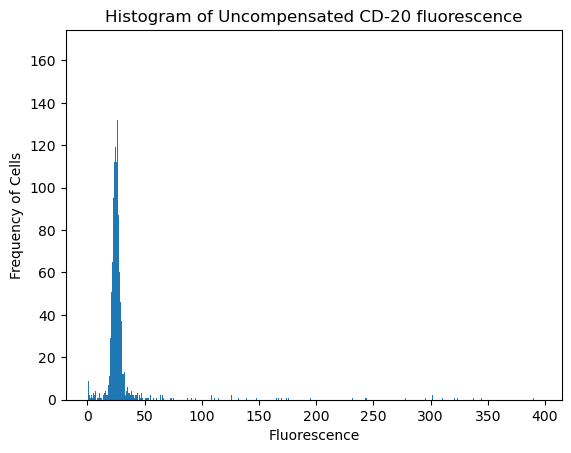

In [78]:
p = plt.hist((CD_20_mean_3[CD_20_mean_3<400]+1), bins=1000)
plt.title("Histogram of Uncompensated CD-20 fluorescence")
plt.xlabel("Fluorescence")
plt.ylabel("Frequency of Cells")
plt.show()

In [79]:
CD_20_pos_cells_uncomp = (CD_20_mean_3>50)
CD_20_pos_cells_uncomp.sum(), len(CD_20_pos_cells_uncomp)

(184, 2706)

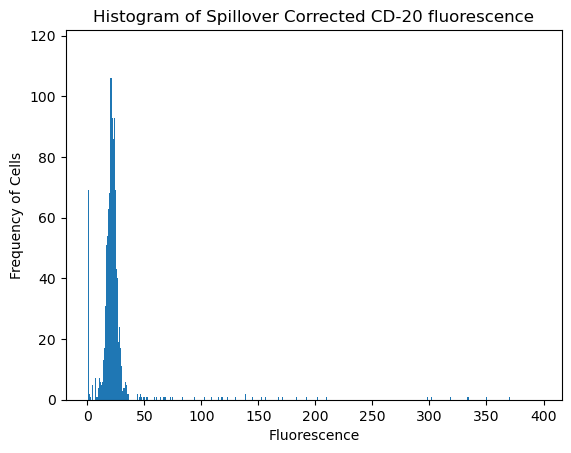

In [80]:
p = plt.hist((CD_20_comp_3[CD_20_comp_3<400]+1), bins=1000)
plt.title("Histogram of Spillover Corrected CD-20 fluorescence")
plt.xlabel("Fluorescence")
plt.ylabel("Frequency of Cells")
plt.show()

In [81]:
CD_20_pos_cells_comp = (CD_20_comp_3>50)
CD_20_pos_cells_comp.sum(), len(CD_20_pos_cells_comp)

(153, 2706)

In [82]:
from scipy.stats import percentileofscore
percentileofscore(CD_20_comp_3, 50), percentileofscore(CD_20_mean_3, 50)

(94.34589800443459, 93.20029563932003)

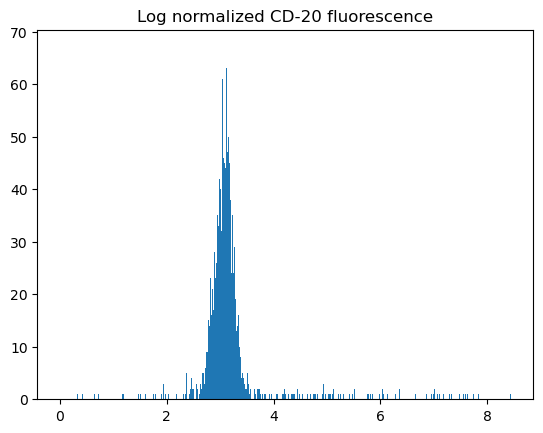

In [83]:
p = plt.hist(np.log(CD_20_comp_3+1), bins=1000)
plt.title("Log normalized CD-20 fluorescence")
plt.show()

In [84]:
percentileofscore(np.log(CD_20_comp_3+1), 3.7)

93.53288987435329

In [85]:
cut_off = 94
CD_20_cutoff = np.percentile(CD_20_comp_3, cut_off)
CD_20_cutoff = 50

In [86]:
np.percentile(CD_20_comp_3, 99)

1054.8169474943609

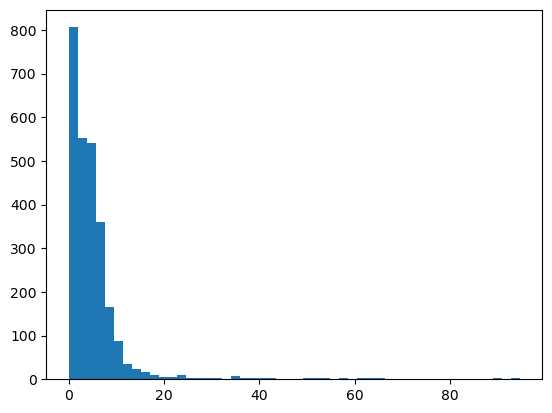

In [87]:
p = plt.hist(abs(CD_20_comp_3-CD_20_mean_3)[abs(CD_20_comp_3-CD_20_mean_3)<100], bins=50)
plt.show()

In [88]:
cut_off_diff = 96
CD_20_diff_cutoff = np.percentile(abs(CD_20_comp_3-CD_20_mean_3), cut_off_diff)
CD_20_diff_cutoff

19.059061858210736

In [89]:
percentileofscore(abs(CD_20_comp_3-CD_20_mean_3), 20)

96.11973392461198

In [90]:
np.sum(np.logical_and(~CD_20_pos_cells_comp, ~CD_20_pos_cells_uncomp))

2521

In [91]:
def get_closest_median(arr):
    median = np.median(arr)
    closest = arr[np.abs(arr - median).argmin()]
    return closest

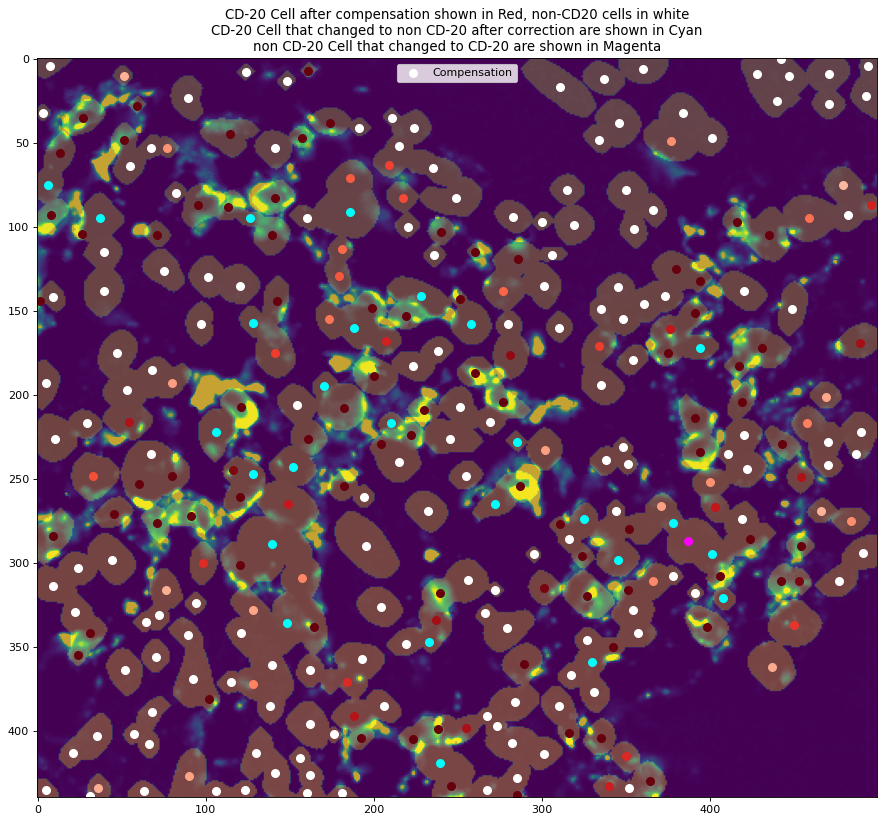

In [92]:
from matplotlib.pyplot import figure
idx1, idx2, idx3, idx4 = 1600, 2040, 0, 500
figure(figsize=(16, 12), dpi=80)
CD_pos_neg = 0
CD_neg_pos = 0
CD_pos = 0
CD_neg = 0
for label in np.unique(mask_dil[idx1:idx2, idx3:idx4]):
    if label!=0:
        rows, columns = np.where(mask_dil[idx1:idx2, idx3:idx4] ==label)
        r_, c_ =  get_closest_median(rows), get_closest_median(columns)
        is_CD_20 = CD_20_pos_cells_comp[label-1]
        was_CD_20 = CD_20_pos_cells_uncomp[label-1]
        value = CD_20_mean_3[label-1]
        comp_value = CD_20_comp_3[label-1]
        
        if was_CD_20 and not is_CD_20:
            plt.scatter(c_,r_, color='cyan', s = 50, )
            CD_pos_neg+=1
            CD_neg+=1
        
        elif not was_CD_20 and not is_CD_20:
            plt.scatter(c_,r_, color='white', s = 50,)
            CD_neg+=1
        
        elif not was_CD_20 and is_CD_20:
            plt.scatter(c_,r_, color='magenta', s = 50,)
            CD_neg_pos+=1
            CD_pos+=1
        else:
            plt.scatter(c_,r_, c= comp_value, vmin = 0, vmax =np.percentile(CD_20_comp_3, 97),
                          s = 50, cmap='Reds', )
            CD_pos+=1
plt.imshow(tile.image[idx1:idx2, idx3:idx4, channel_names.index('CD20')], vmax=3000)
plt.imshow(mask_dil[idx1:idx2, idx3:idx4],alpha=0.3)

plt.title("CD-20 Cell after compensation shown in Red, non-CD20 cells in white\n" + 
                "CD-20 Cell that changed to non CD-20 after correction are shown in Cyan\n"+
         "non CD-20 Cell that changed to CD-20 are shown in Magenta")
plt.legend(['Compensation'], markerscale=1, loc = "upper center")

plt.show()

In [93]:
CD_pos_neg, CD_neg_pos, CD_pos, CD_neg, len(np.unique(mask_dil[idx1:idx2, idx3:idx4]))-1

(26, 1, 131, 179, 310)

In [55]:
# from matplotlib.pyplot import figure
# idx1, idx2, idx3, idx4 = 1600, 2040, 0, 500
# figure(figsize=(15, 12), dpi=80)
# for label in np.unique(mask_dil[idx1:idx2, idx3:idx4]):
#     if label!=0:
#         rows, columns = np.where(mask_dil[idx1:idx2, idx3:idx4] ==label)
#         r_, c_ =  get_closest_median(rows), get_closest_median(columns)
#         is_CD_20 = CD_20_pos_cells_comp[label-1]
#         was_CD_20 = CD_20_pos_cells_uncomp[label-1]
#         value = CD_20_mean_3[label-1]
#         comp_value = CD_20_comp_3[label-1]
        
#         if abs(comp_value-value) <  CD_20_diff_cutoff:
#             plt.scatter(c_,r_, color='white', s = 40, marker="D", alpha = 0.8)
            
#         else:
#             plt.scatter(c_,r_, c= (comp_value - value), vmin = -100,
#                           vmax =100, s = 40, marker="D", cmap='bwr', alpha = 0.8)
            
#         if was_CD_20 and not is_CD_20:
#             plt.scatter(c_,r_, color='cyan', s = 15, )
        
#         elif not was_CD_20 and not is_CD_20:
#             plt.scatter(c_,r_, color='white', s = 3,)
        
#         elif not was_CD_20 and is_CD_20:
#             plt.scatter(c_,r_, color='magenta', s = 15,)
#         else:
#             plt.scatter(c_,r_, c= comp_value, vmin = 0, vmax =np.percentile(CD_20_comp_3, 97),
#                           s = 15, cmap='Reds', )

# plt.imshow(tile.image[idx1:idx2, idx3:idx4, channel_names.index('CD20')], vmax=3000)
# plt.imshow(mask_dil[idx1:idx2, idx3:idx4],alpha=0.3)

# plt.title("CD-20 Cell spillover Correction: -ve change shown in Blue, +ve change in Red\n" + 
#                 "CD-20 cells are colored in Red Circles")
# plt.legend(['Compensation', 'CD-20 fluorescence'], markerscale=1, loc = "upper center")

# plt.show()

In [56]:
CD_68_pos_cells_uncomp = (CD_68_mean_3>500)
CD_68_pos_cells_uncomp.sum(), len(CD_68_pos_cells_uncomp)

(306, 2706)

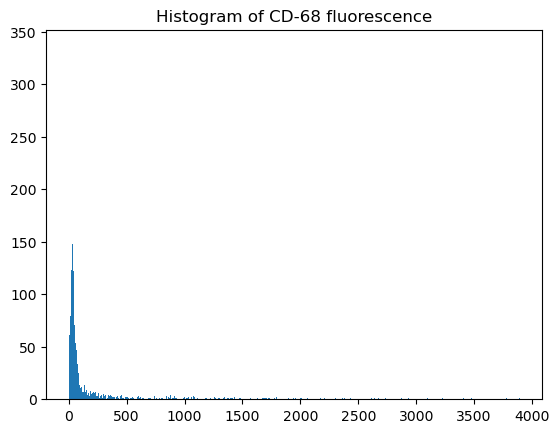

In [57]:
p = plt.hist((CD_68_comp_3[CD_68_comp_3<4000]+1), bins=1000)
plt.title("Histogram of CD-68 fluorescence")
plt.show()

In [58]:
CD_68_pos_cells_comp = (CD_68_comp_3>500)
CD_68_pos_cells_comp.sum(), len(CD_68_pos_cells_comp)

(269, 2706)

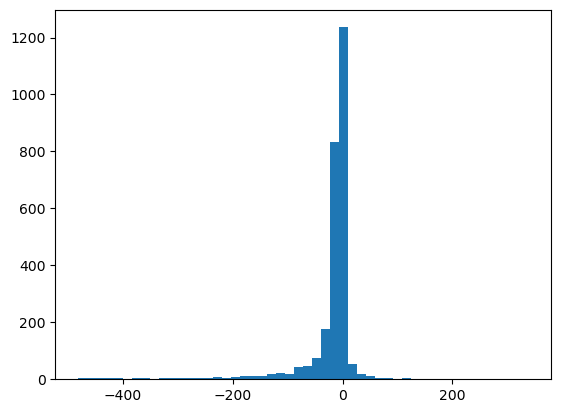

In [59]:
p = plt.hist((CD_68_comp_3-CD_68_mean_3)[abs(CD_68_comp_3-CD_68_mean_3)<500], bins=50)
plt.show()

In [60]:
cut_off_diff = 90
CD_68_diff_cutoff = np.percentile(abs(CD_68_comp_3-CD_68_mean_3), cut_off_diff)
CD_68_diff_cutoff

63.875152653783005

In [61]:
percentileofscore(CD_68_comp_3, 500), percentileofscore(CD_68_mean_3, 500)

(90.05912786400592, 88.69179600886918)

In [62]:
percentileofscore(CD_20_mean_3, 258)

96.8218773096822

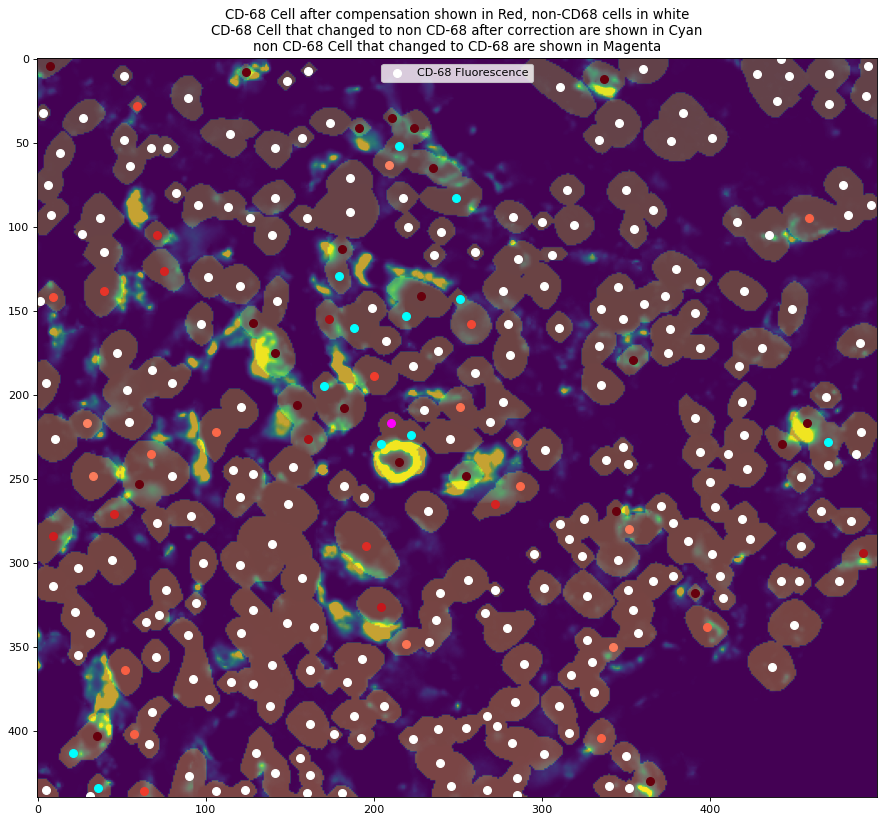

In [63]:
from matplotlib.pyplot import figure
idx1, idx2, idx3, idx4 = 1600, 2040, 0, 500
figure(figsize=(16, 12), dpi=80)
CD_pos_neg = 0
CD_neg_pos = 0
CD_pos = 0
CD_neg = 0
for label in np.unique(mask_dil[idx1:idx2, idx3:idx4]):
    if label!=0:
        rows, columns = np.where(mask_dil[idx1:idx2, idx3:idx4] ==label)
        r_, c_ =  get_closest_median(rows), get_closest_median(columns)
        is_CD_68 = CD_68_pos_cells_comp[label-1]
        was_CD_68 = CD_68_pos_cells_uncomp[label-1]
        value = CD_68_mean_3[label-1]
        comp_value = CD_68_comp_3[label-1]
        
        if was_CD_68 and not is_CD_68:
            plt.scatter(c_,r_, color='cyan', s = 50, )
            CD_pos_neg+=1
            CD_neg+=1
        
        elif not was_CD_68 and not is_CD_68:
            plt.scatter(c_,r_, color='white', s = 50,)
            CD_neg+=1
        
        elif not was_CD_68 and is_CD_68:
            plt.scatter(c_,r_, color='magenta', s = 50,)
            CD_neg_pos+=1
            CD_pos+=1
        else:
            plt.scatter(c_,r_, c= comp_value, vmin = 0, vmax =np.percentile(CD_68_comp_3, 95),
                          s = 50, cmap='Reds', )
            CD_pos+=1
plt.imshow(tile.image[idx1:idx2, idx3:idx4, channel_names.index('CD68')], vmax=10000)
plt.imshow(mask_dil[idx1:idx2, idx3:idx4],alpha=0.3)

plt.title("CD-68 Cell after compensation shown in Red, non-CD68 cells in white\n" + 
                "CD-68 Cell that changed to non CD-68 after correction are shown in Cyan\n"+
         "non CD-68 Cell that changed to CD-68 are shown in Magenta")
plt.legend(['CD-68 Fluorescence'], markerscale=1, loc = "upper center")

plt.show()

In [64]:
CD_pos_neg, CD_neg_pos, CD_pos, CD_neg

(12, 1, 56, 254)

In [70]:
# mask_dil_2 =grow_masks(mask_reindexed, 2, method = 'Standard', num_neighbors = 30)

Standard growth selected


In [72]:
# comp_mean_2, mean_2, areas_2 = convert_seg_to_CVMask(mask_dil, tile.image)

In [73]:
# CD_20_comp_2 = comp_mean_2[:, channel_names.index('CD20')]
# CD_20_mean_2 = mean_2[:, channel_names.index('CD20')]
# p = plt.hist((CD_20_mean_2[CD_20_mean_2<400]+1), bins=1000)
# plt.title("Histogram of Uncompensated CD-20 fluorescence")
# plt.show()

In [65]:
# Use int and not numpy int
mask_dil = mask_dil.astype(int)
mask_new = mask_new.astype(int)

In [66]:
def get_str_elem(elememt_shape, element_size=2):
    if element_shape == "diamond":
        structuring_element = skimage.morphology.diamond(element_size)
    elif element_shape == "square":
        # square is initialized with full width, so need to convert from width from center used by other elements
        square_size = element_size * 2 + 1
        structuring_element = skimage.morphology.square(square_size)
    elif element_shape == "disk":
        structuring_element = skimage.morphology.disk(element_size)
    elif element_shape == "star":
        structuring_element = skimage.morphology.star(element_size)
    else:
        structuring_element = None

    assert structuring_element.shape[0] % 2 == 1, \
        f"invalid structuring element shape: {structuring_element.shape}. Must have odd dimensions so that" \
        f"element can be centered on a single pixel."
    element_size = int((structuring_element.shape[0] - 1) / 2)
    return structuring_element, element_size

In [67]:
element_shape = "diamond"
structuring_element, element_size = get_str_elem(element_shape, element_size=4)
segmentation_mask = "nuclear_segmentation"

In [68]:
structuring_element

array([[0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 1, 1, 1, 1, 1, 0, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 1, 1, 0, 0],
       [0, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0]], dtype=uint8)

In [69]:
element_size, structuring_element.shape

(4, (9, 9))

In [70]:
def _mask_to_border_mask(mask, structuring_element, element_size):
        """
        Converts a mask to a border-only mask.
        Loops through all pixels in the input mask, applies structuring element to get adjacent pixels, and
        and keeps the pixel only if a boundary region (i.e., zero pixel) is among the neighbors. Otherwise,
        sets the pixel to zero as a non-boundary pixel.

        Args:
            mask (np.ndarray): (h, w) segmentation mask. Zeros are background, and pixels belonging to each of n
                cells are labelled with unique integers, with a line of zeros separating adjacent regions.
            element_size (int): width of structuring element used to determine if the pixel is a boundary pixel.
                Defaults to 2.
            element_shape (str): shape of structuring element used to determine if the pixel is a boundary pixel.
                Defaults to "diamond" to use ``skimage.morphology.diamond``

        Returns:
            np.ndarray: Segmentation mask of same shape as input, with zeros for non-boundary pixels
        """
        assert mask.ndim == 2, f"input mask has shape {mask.shape} but must be (h, w)"

        border_mask = np.copy(mask)

        elem_loc = np.where(structuring_element == 1)
        # offset so that the location indices are centered on the structuring element
        elem_loc_i, elem_loc_j = [c - element_size for c in elem_loc]

        # loop over pixels
        for i in range(mask.shape[0]):
            for j in range(mask.shape[1]):
                # loop thru structuring element
                border = False
                for di, dj in zip(elem_loc_i, elem_loc_j):
                    if 0 <= i + di <= mask.shape[0] - 1 and 0 <= j + dj <= mask.shape[0] - 1:
                        if mask[i + di, j + dj] == 0:
                            # zero pixel means that it's a boundary pixel
                            # bigger element size --> thicker boundary
                            border = True
                if not border:
                    # in this case, no zero pixels were found, so it's not a border pixel
                    border_mask[i, j] = 0
        return border_mask

In [71]:
def get_segmentation_zero_boundary(segmentation):
        """
        Takes as input a segmentation mask, and adds a 1px-wide line of zero pixels between labelled regions.
        These zero boundary pixels are relied on in later steps of the algorithm.
        Note that skimage.segmentation.watershed does have a ``watershed_line`` parameter that is supposed to do this,
        but it is buggy (See: https://github.com/scikit-image/scikit-image/issues/6279) so this is a simple
        reimplementation using morphological operations

        Args:
            segmentation (np.ndarray): Segmentation mask. Zeros are background, and pixels belonging to each of n
                cells are labelled with integers 1 to n.

        Returns:
            np.ndarray: Segmentation mask. Zeros are background, and pixels belonging to each of n
                cells are labelled with integers 1 to n, with a line of zeros separating adjacent regions.
        """
        boundaries = skimage.segmentation.find_boundaries(segmentation, connectivity = 1, mode = "inner")
        # this step thins out boundaries that are >1 px wide
        boundaries = skimage.morphology.thin(boundaries)
        # zero out the boundary pixels that we identified
        segmentation[boundaries] = 0
        return segmentation

In [72]:
def _compute_pairwise_matrix(mask, structuring_element):
        """
        Computes perimeters of each cell, and pairwise compensation values for each pair.
        Uses a 3x3 structuring element.
        Note that labels are counted starting at 1, but array is indexed starting at 0

        Args:
            mask (np.ndarray): (h, w) segmentation mask. Zeros are background, and pixels belonging to each of n
                cells are labelled with integers 1 to n, with a line of zeros separating adjacent regions.

        Returns:
            np.ndarray: (n_cells, n_cells) array where the i,jth element gives b_ij / P_j, i.e. the number of boundary pixels
                between cells i and j divided by the total perimeter of cell j.
        """
        labels = np.unique(mask)
        # remove zero label (background pixels)
        labels = [item for item in labels if item != 0]
        n_cells = len(labels)

        # check to make sure that labels are consecutive
        assert n_cells == np.max(mask), "labels must be consecutive ints from 1:n"

        # Add a padding of zeros around outside as well
        # Since zero pixels are used to count cell perimeters, this is necessary otherwise perimeter will be
        # underestimated for cells touching image border
        mask = np.pad(mask, pad_width = 1, mode = 'constant', constant_values = 0)

        cell_perimeters = np.zeros(n_cells)
        cell_adjacencies = np.zeros((n_cells, n_cells))  # cell-cell shared perimeter matrix container

        zero_ind_i, zero_ind_j = np.where(mask == 0)
        for i, j in zip(zero_ind_i, zero_ind_j):
            # offsets for a 3x3 structuring element centered on i,j
            adj_labels = []
#             for di, dj in itertools.product([-1, 0, 1], repeat = 2):
            elem_loc = np.where(structuring_element == 1)
        # offset so that the location indices are centered on the structuring element
            elem_loc_i, elem_loc_j = [c - structuring_element.shape[0]//2+1 for c in elem_loc]
            for di, dj in zip(elem_loc_i, elem_loc_j):
                if 0 <= i + di <= mask.shape[0] - 1 and 0 <= j + dj <= mask.shape[1] - 1:
                    label = mask[i + di, j + dj]
                    if label != 0 and label not in adj_labels:
                        adj_labels.append(label)
                        
            # increment perimeter counts
            # need to subtract 1 because labels start at 1 but index starts at 0
            for label in adj_labels:
                cell_perimeters[int(label) - 1] += 1

            # increment shared perimeter counts
            # need to subtract 1 because labels start at 1 but index starts at 0
            for label1, label2 in itertools.permutations(adj_labels, 2):
                cell_adjacencies[label1 - 1, label2 - 1] += 1

        # raise if any of the cell perimeters are zero, since this will introduce NaNs in the next division step
        # also this really shouldn't ever happen, since every region has to have a perimeter>0
        if np.any(cell_perimeters == 0):
            raise ValueError("Cell perimeters in _compute_pairwise_matrix() contains zeros!!")

        # divide to get fraction
#         cell_adjacencies = cell_adjacencies / cell_perimeters

        return cell_adjacencies, cell_perimeters


In [73]:
 def compute_redsea_counts_matrix(img, mask, structuring_element, element_size):
        """
        Computes counts matrix using REDSEA algorithm

        Args:
            img (np.ndarray): (h, w, n_channels) Input image
            mask (np.ndarray): (h, w) segmentation mask. Zeros are background, and pixels belonging to each of n cells
                are labelled with integers, with a line of zeros separating adjacent regions.
                Labels will be relabeled from 1 to n.

        Returns:
            np.ndarray: counts matrix (n_cells, n_channels)
        """
        # make sure that labels are 1:n
        # this is relied upon later, when NxN matrix is indexed using cell labels
        mask, _, _ = relabel_sequential(mask)

        labels = np.unique(mask)
        # remove zero label (background pixels)
        labels = [item for item in labels if item != 0]
        n_cells = len(labels)
        # check to make sure that labels are consecutive
        assert n_cells == np.max(mask), "labels must be consecutive ints from 1:n"

        n_channels = img.shape[2]

        # get border mask
        mask_border = _mask_to_border_mask(
            mask,
            structuring_element = structuring_element,
            element_size = element_size
        )

        # get cell-cell interaction matrix
        cell_pair_weights = _compute_pairwise_matrix(mask, structuring_element)

        counts = np.empty((n_cells, n_channels))
        counts_border = np.empty((n_cells, n_channels))
        cell_sizes = np.empty(n_cells)

        # fill counts matrix and border counts matrix, and cell size
        for label in labels:
            counts_lab = img[mask == label].sum(axis = 0)
            counts_border_lab = img[mask_border == label].sum(axis = 0)

            cell_sizes[label - 1] = np.sum(mask == label)
            counts[label - 1, :] = counts_lab
            counts_border[label - 1, :] = counts_border_lab
        print(counts_border)

        # computes the weighted sum of border counts, to be subtracted
        counts_subtract = cell_pair_weights @ counts_border

        # now apply reinforcement and subtraction
        counts_redsea = counts + counts_border - counts_subtract
        
        # normalize by cell area
        counts_redsea = np.diag([1 / cell_size for cell_size in cell_sizes]) @ counts_redsea
        # clip negative values to 0
        counts_redsea = counts_redsea.clip(0)

        return counts_redsea


In [74]:
def F(img, segmentation, coords_offset=(0, 0), structuring_element=structuring_element, element_size=element_size):
        """
        Functional implementation of marker quantification using the REDSEA algorithm

        Args:
            img (np.ndarray): (h, w, n_channels) Input image
            segmentation (np.ndarray): (h, w) segmentation mask. Zeros are background, and pixels belonging to each of n cells
                are labelled with integers, with a line of zeros separating adjacent regions.
                Labels will be relabeled from 1 to n.
            coords_offset (tuple, optional): Coordinates (i, j) used to convert tile-level coordinates to slide-level.
                Defaults to (0, 0) for no offset.

        Returns:
            anndata.AnnData: Counts matrix
        """
        if segmentation.ndim == 3 and segmentation.shape[2] == 1:
            segmentation = segmentation.squeeze(axis = 2)

        assert segmentation.ndim == 2 and segmentation.shape == img.shape[0:2] and img.ndim == 3, \
            f"segmentation of shape {segmentation.shape} does not match image of shape {img.shape}. " \
            f"Must be of shapes (i, j) and (i, j, n_channels), respectively."

        segmentation_zero_boundary = get_segmentation_zero_boundary(segmentation.copy())

        counts_redsea = compute_redsea_counts_matrix(img=img, mask=segmentation_zero_boundary,
                                                     structuring_element=structuring_element,
                                                     element_size=element_size)

        ### this part copied from QuantifyMIF
        countsdataframe = regionprops_table(
            label_image = segmentation,
            intensity_image = img,
            properties = [
                "label",
                "coords",
                "centroid",
                "filled_area",
                "euler_number",
            ],
        )
        # populate anndata object
        # i,j are relative to the input image (0 to img.shape). Adding offset converts to slide-level coordinates
        counts = anndata.AnnData(
            X = counts_redsea,
            obs = [
                tuple([i + coords_offset[0], j + coords_offset[1]])
                for i, j in zip(
                    countsdataframe["centroid-0"], countsdataframe["centroid-1"]
                )
            ],
        )
        counts.obs["label"] = countsdataframe["label"]
        counts.obs = counts.obs.rename(columns = {0: "y", 1: "x"})
        counts.obs["filled_area"] = countsdataframe["filled_area"]
        counts.obs["euler_number"] = countsdataframe["euler_number"]
        try:
            counts.obsm["spatial"] = np.array(counts.obs[["x", "y"]])
        except:
            print("warning: did not log coordinates in obsm")
        return counts

In [75]:
tile.coords

(1848, 1848)

In [76]:
structuring_element

array([[0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 1, 1, 1, 1, 1, 0, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 1, 1, 0, 0],
       [0, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0]], dtype=uint8)

In [77]:
tile.masks[segmentation_mask].max()

2716.0

In [78]:
tile.image.shape

(2048, 2048, 42)

In [79]:
idx1, idx2, idx3, idx4 = 1600, 2040, 0, 500

In [80]:
tile.coords

(1848, 1848)

In [81]:
len(np.unique(mask_new))

2383

In [82]:
# counts_redsea = F(
#             img = tile.image,
#             segmentation = relabel_sequential(mask_dil[idx1:idx2, idx3:idx4].copy())[0],
#             coords_offset = tile.coords,
#         )

In [83]:
mask_sm = relabel_sequential(mask_dil.copy())[0]

In [84]:
element_shape = "diamond"
structuring_element, element_size = get_str_elem(element_shape, element_size=4)
segmentation_mask = "nuclear_segmentation"


In [85]:
structuring_element.shape, element_size

((9, 9), 4)

In [86]:
structuring_element

array([[0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 1, 1, 1, 1, 1, 0, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 1, 1, 0, 0],
       [0, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0]], dtype=uint8)

In [87]:
%%time
cell_adjecencies, cell_perimeters = _compute_pairwise_matrix(mask_sm, 
                                             structuring_element=structuring_element)

CPU times: user 5min 54s, sys: 311 ms, total: 5min 55s
Wall time: 5min 55s


In [88]:
(cell_adjecencies/cell_perimeters).max()

0.9047619047619048

In [89]:
cell_pair_weights = cell_adjecencies/cell_perimeters

In [90]:
cell_pair_weights.shape

(2706, 2706)

In [91]:
# cell_pair_weights = _compute_pairwise_matrix(mask_sm,structuring_element=skimage.morphology.diamond(3))

In [92]:
cell_pair_weights.max(), (cell_pair_weights!=0).sum()

(0.9047619047619048, 6846)

In [93]:
cell_pair_weights_self = cell_adjecencies.sum(axis=1)/cell_perimeters

In [94]:
%%time
mask_border1 = _mask_to_border_mask(
            mask_sm,
            structuring_element = structuring_element,
            element_size = element_size
        )

CPU times: user 8min 29s, sys: 576 ms, total: 8min 29s
Wall time: 8min 30s


In [95]:
mask_border1.shape

(2048, 2048)

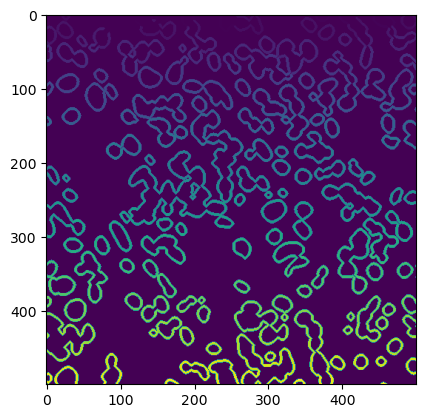

In [96]:
plt.imshow(mask_border1[:500, :500]) 

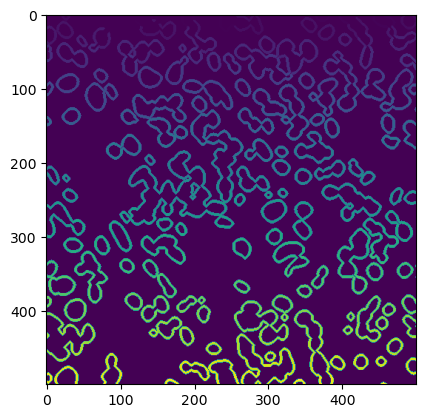

In [97]:
plt.imshow(mask_border1[:500, :500]) #elem_size = 4

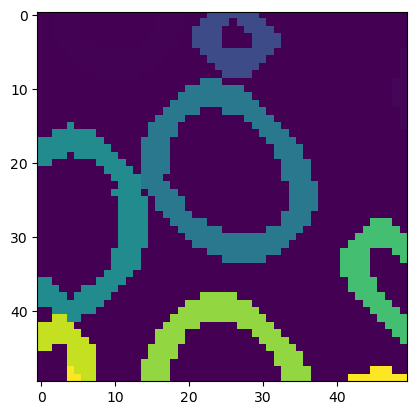

In [98]:
plt.imshow(mask_border1[:50, :50]) #elem_size = 2

In [99]:
# plt.imshow(mask_border[:50, :50])

In [100]:
np.unique(mask_sm)

array([   0,    1,    2, ..., 2704, 2705, 2706])

In [101]:
%%time
img = tile.image.copy()
n_cells = mask_sm.max()
cell_sizes = np.empty(n_cells)
n_channels = img.shape[2]
counts = np.empty((n_cells, n_channels))
counts_border = np.empty((n_cells, n_channels))
for label in np.unique(mask_sm):
    counts_lab = img[mask_sm == label].sum(axis = 0)
    counts_border_lab = img[mask_border1 == label].sum(axis = 0)

    cell_sizes[label - 1] = np.sum(mask_sm == label)
    counts[label - 1, :] = counts_lab
    counts_border[label - 1, :] = counts_border_lab

CPU times: user 1min 37s, sys: 2.25 s, total: 1min 39s
Wall time: 1min 39s


In [102]:
counts_border.shape, img.shape

((2706, 42), (2048, 2048, 42))

In [103]:
cell_pair_weights_self.shape

(2706,)

In [104]:
# reinforced = cell_pair_weights_self.reshape((-1, 1)) * counts_border


# https://www.frontiersin.org/articles/10.3389/fimmu.2021.652631/full
# If we didn't approximate in equation 5 (adjacent cells don't typically overlap the 
# cell boundary. However, equation 5 assumes that.) If we didn't assume that, we would calculate the
# overlapping fraction % in reinforced signal this way.

In [105]:
reinforced = counts_border.copy()

In [106]:
reinforced.shape

(2706, 42)

In [107]:
counts_subtract = cell_pair_weights @ counts_border
counts_subtract

array([[ 3640.85772947,  2149.12391304,   974.97910628, ...,
         3652.89927536,  3631.57379227,  2061.64142512],
       [ 7231.23588725,  3943.13994347,  1756.45260102, ...,
         7447.79443893,  6800.32617829,  3718.09808265],
       [11507.38541386,  6232.15358749,  2719.03751687, ...,
        11897.19429825, 10896.86210076,  5855.73444669],
       ...,
       [ 2720.55405405,  1602.72972973,   721.21621622, ...,
         3035.43243243,  2770.66216216,  1474.41891892],
       [ 2241.04740741,  1339.48      ,   614.1837037 , ...,
         2442.88444444,  2262.19555556,  1254.32444444],
       [ 2698.52631579,  1674.79532164,   828.35087719, ...,
         2803.74269006,  2903.02923977,  1673.57894737]])

In [108]:
counts_subtract.max()

2938306.7734978977

In [160]:

# now apply reinforcement and subtraction
alpha=1
counts_redsea = counts + alpha*reinforced - counts_subtract

# normalize by cell area
counts_redsea = np.diag([1 / cell_size for cell_size in cell_sizes]) @ counts_redsea
counts_uncomp = np.diag([1 / cell_size for cell_size in cell_sizes]) @ counts
# clip negative values to 0
counts_redsea = counts_redsea.clip(0)


In [161]:
counts_redsea

array([[261.20265326, 144.27035726,  69.79861158, ..., 267.48140097,
        247.2823737 , 135.56091919],
       [239.65434538, 131.13685853,  59.93926416, ..., 248.22833089,
        228.03025182, 126.85819008],
       [222.70932431, 121.25187259,  53.84726213, ..., 235.89116306,
        203.04676526, 110.28156096],
       ...,
       [217.40699222, 131.34572072,  59.62039312, ..., 257.06275594,
        230.89900696, 128.39235258],
       [190.66639883, 112.23457627,  54.89726721, ..., 204.01760201,
        193.21358443, 110.65353421],
       [214.7556391 , 140.09767474,  67.06725146, ..., 228.47925369,
        224.65441381, 126.76691729]])

In [162]:
counts_uncomp

array([[176.65116279,  97.68217054,  46.73643411, ..., 181.41085271,
        166.05426357,  91.71317829],
       [181.04424779,  98.36283186,  45.02876106, ..., 189.90707965,
        172.11504425,  96.20132743],
       [188.26327434, 101.91814159,  45.24557522, ..., 200.16150442,
        170.93362832,  93.19690265],
       ...,
       [160.51893939,  96.96969697,  44.85227273, ..., 191.14393939,
        171.28787879,  95.81818182],
       [160.29378531,  93.5819209 ,  46.19774011, ..., 170.60451977,
        161.40112994,  92.42937853],
       [154.88095238, 100.73809524,  48.86904762, ..., 164.10714286,
        163.71428571,  92.3452381 ]])

In [163]:
counts_redsea.max()

54045.76859471694

In [164]:
counts_redsea.shape

(2706, 42)

In [165]:
CD_20_comp_3_redsea = counts_redsea[:, channel_names.index('CD20')]

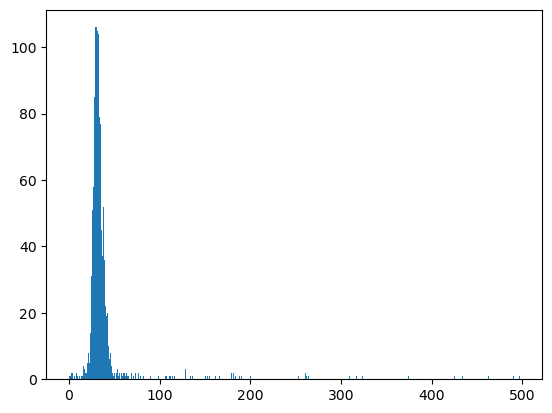

In [166]:
p = plt.hist(CD_20_comp_3_redsea[CD_20_comp_3_redsea<500], bins=1000)
plt.show()

In [167]:
CD_20_uncomp_3_redsea = counts_uncomp[:, channel_names.index('CD20')]

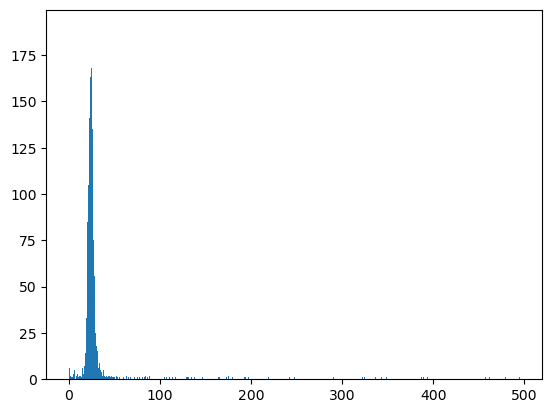

In [168]:
p = plt.hist(CD_20_uncomp_3_redsea[CD_20_uncomp_3_redsea<500], bins=1000)


In [169]:
percentileofscore(CD_20_uncomp_3_redsea, 1000)

98.92830746489282

In [170]:
cutoff_CD_20 = np.percentile(CD_20_uncomp_3_redsea, 94)

In [171]:
cutoff_CD_20

63.094687943262386

In [172]:
CD_20_pos_cells_comp_r = CD_20_comp_3_redsea>50
CD_20_pos_cells_uncomp_r = CD_20_uncomp_3_redsea>50

In [173]:
CD_20_pos_cells_uncomp.sum(), len(CD_20_pos_cells_uncomp)

(184, 2706)

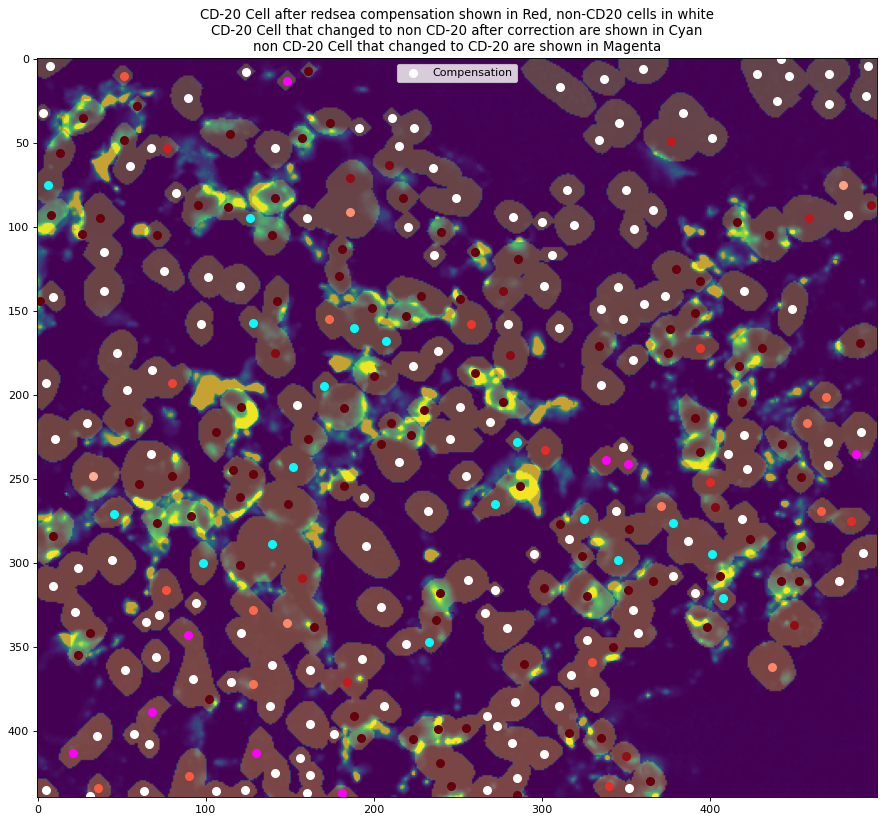

In [174]:
from matplotlib.pyplot import figure
idx1, idx2, idx3, idx4 = 1600, 2040, 0, 500
figure(figsize=(16, 12), dpi=80)
CD_pos_neg_r = 0
CD_neg_pos_r = 0
CD_pos_r = 0
CD_neg_r = 0
for label in np.unique(mask_dil[idx1:idx2, idx3:idx4]):
    if label!=0:
        rows, columns = np.where(mask_dil[idx1:idx2, idx3:idx4] ==label)
        r_, c_ =  get_closest_median(rows), get_closest_median(columns)
        is_CD_20 = CD_20_pos_cells_comp_r[label-1]
        was_CD_20 = CD_20_pos_cells_uncomp_r[label-1]
        value = CD_20_uncomp_3_redsea[label-1]
        comp_value = CD_20_comp_3_redsea[label-1]
        
        if was_CD_20 and not is_CD_20:
            plt.scatter(c_,r_, color='cyan', s = 50, )
            CD_pos_neg_r+=1
            CD_neg_r+=1
        
        elif not was_CD_20 and not is_CD_20:
            plt.scatter(c_,r_, color='white', s = 50,)
            CD_neg_r+=1
        
        elif not was_CD_20 and is_CD_20:
            plt.scatter(c_,r_, color='magenta', s = 50,)
            CD_neg_pos_r+=1
            CD_pos_r+=1
        else:
            plt.scatter(c_,r_, c= comp_value, vmin = 0, vmax =np.percentile(CD_20_comp_3, 97),
                          s = 50, cmap='Reds', )
            CD_pos_r+=1
plt.imshow(tile.image[idx1:idx2, idx3:idx4, channel_names.index('CD20')], vmax=3000)
plt.imshow(mask_dil[idx1:idx2, idx3:idx4],alpha=0.3)

plt.title("CD-20 Cell after redsea compensation shown in Red, non-CD20 cells in white\n" + 
                "CD-20 Cell that changed to non CD-20 after correction are shown in Cyan\n"+
         "non CD-20 Cell that changed to CD-20 are shown in Magenta")
plt.legend(['Compensation'], markerscale=1, loc = "upper center")

plt.show()

In [175]:
CD_pos_neg_r, CD_neg_pos_r, CD_pos_r, CD_neg_r

(18, 9, 147, 163)

In [176]:
21/156

0.1346153846153846

In [177]:
CD_pos_neg, CD_neg_pos, CD_pos, CD_neg, len(np.unique(mask_dil[idx1:idx2, idx3:idx4]))-1

(12, 1, 56, 254, 310)

In [178]:
import numpy as np

def count_equal_values(arr1, arr2, value):
    # check if the shapes of the arrays are the same
    if arr1.shape != arr2.shape:
        raise ValueError("Input arrays must have the same shape.")
    
    # compare the values of the arrays to the specific value and count the number of matches
    equal_values = np.sum(np.logical_and(arr1 == value, arr2 == value))
    
    return equal_values


In [179]:
count_equal_values(CD_20_pos_cells_comp, CD_20_pos_cells_comp_r, False)

2488

In [180]:
count_equal_values(CD_20_pos_cells_comp, CD_20_pos_cells_comp_r, True)

149

In [181]:
np.sum(np.logical_and(CD_20_pos_cells_comp == True, CD_20_pos_cells_comp_r == False))

4

In [219]:
np.sum(np.logical_and(CD_20_pos_cells_comp == False, CD_20_pos_cells_comp_r == True))

33

In [227]:
np.sum(np.logical_and(CD_20_pos_cells_uncomp == True, CD_20_pos_cells_comp==False,
                      CD_20_pos_cells_comp_r == False))

32

In [231]:
np.sum(np.logical_and(np.logical_and(CD_20_pos_cells_uncomp == True, CD_20_pos_cells_comp == False),
                                     CD_20_pos_cells_comp_r == False))


17

In [232]:
np.sum(np.logical_and(CD_20_pos_cells_uncomp == True, CD_20_pos_cells_comp == False),
                                     )


32

In [229]:
np.sum(np.logical_and(CD_20_pos_cells_uncomp_r == True, CD_20_pos_cells_comp_r==False,
                      ))

23

In [143]:
# More cells turn to Pos from Neg due to reinforcement on borders. If there is more signal on border,
# than from neighboring cells, the cells will gain signals
# Can control by only applying a fraction of signal on borders.
# Amount of correction depends on how big is the "border" controlled by structring element size. Higher
# size of structuring elements lead to more correction. 

In [ ]:
# 'CD3e', 'CD4', 'CD8', 'CD68', 'CD20', 'CD31', 'Pancytokeratin'

In [182]:
idx = [channel_names.index('CD3e'), channel_names.index('CD4'), channel_names.index('CD8'), 
       channel_names.index('CD68'), channel_names.index('CD20'), channel_names.index('CD31'),
       channel_names.index('Pancytokeratin')]

In [183]:
import numpy as np

def standardize_and_clip(array, a_min=None, a_max=None):
    # Calculate mean and standard deviation along the channels (axis=2)
    mean = np.mean(array, axis=0)
    std = np.std(array, axis=0)
    
    # Standardize the array along each channel
    standardized = (array - mean) / std
    
    # Clip the standardized array to the specified range
    if a_min is not None and a_max is not None:
        clipped = np.clip(standardized, a_min, a_max)
    
        return clipped
    else:
        return standardized


In [186]:
counts_redsea_umap = counts_redsea[:, idx]
counts_ls_umap = comp_mean_3[:, idx]
counts_ls_uncomp_umap = mean_3[:, idx]


In [187]:
counts_redsea_umap - np.mean(counts_redsea_umap, axis=0)

array([[ 874.47088441, 1005.95189561, -104.87579247, ...,  -39.70346867,
         -65.17381363, -363.27640638],
       [-143.35384116,  -81.43512779,   40.83517899, ...,  -43.74753977,
         -54.33571127, -386.0861268 ],
       [ 190.91267987,  284.37068539, -103.387973  , ...,  -43.63050377,
         -72.44949858, -333.45660141],
       ...,
       [ -76.0652114 ,  -88.67716613,  -93.82035635, ...,    4.83209356,
         217.86069342, -379.0670826 ],
       [ 544.31866009,  445.33649184,  616.82177606, ...,  455.16277812,
         -70.46540006, -423.47503616],
       [ 113.1476063 ,  -19.74935687,   -5.76990275, ...,  -37.62220716,
         -59.12483111, -210.12414479]])

In [188]:
counts_redsea_umap_std = standardize_and_clip(counts_redsea_umap, a_max=6, a_min=-6)

In [189]:
counts_ls_umap_std = standardize_and_clip(counts_ls_umap, a_max=6, a_min=-6)
counts_ls_uncomp_umap_std = standardize_and_clip(counts_ls_uncomp_umap, a_max=6, a_min=-6)

In [190]:
import numpy as np
import umap

In [191]:


def create_umap_embeddings(array, n_neighbors=15, min_dist=0.1):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist)
    embeddings = reducer.fit_transform(array)
    return embeddings
def plot_umap_embeddings(embeddings, s=5):
    
    plt.scatter(embeddings[:, 0], embeddings[:, 1], s=s)
    plt.show()

In [192]:
embeddings_redsea = (create_umap_embeddings(counts_redsea_umap_std, n_neighbors=15))

In [193]:
embeddings_ls = (create_umap_embeddings(counts_ls_umap_std, n_neighbors=15))
embeddings_uncomp = (create_umap_embeddings(counts_ls_uncomp_umap_std, n_neighbors=15))

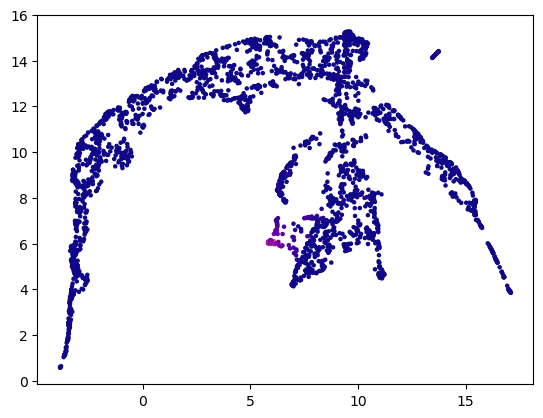

In [200]:
# plot_umap_embeddings(embeddings_uncomp, s=3)
plt.scatter(embeddings_uncomp[:, 0], embeddings_uncomp[:, 1], s=5, c=counts_ls_uncomp_umap[:, 4], cmap='plasma')


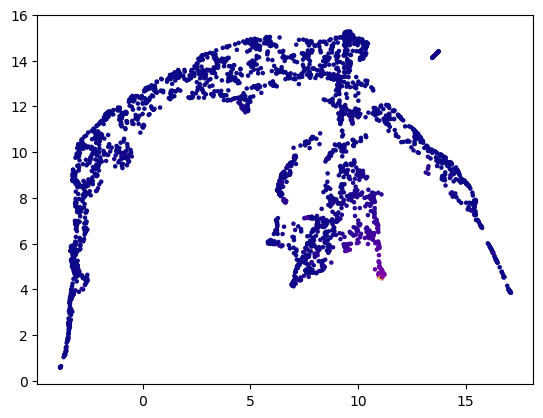

In [201]:
plt.scatter(embeddings_uncomp[:, 0], embeddings_uncomp[:, 1], s=5, c=counts_ls_uncomp_umap[:, 3], cmap='plasma')


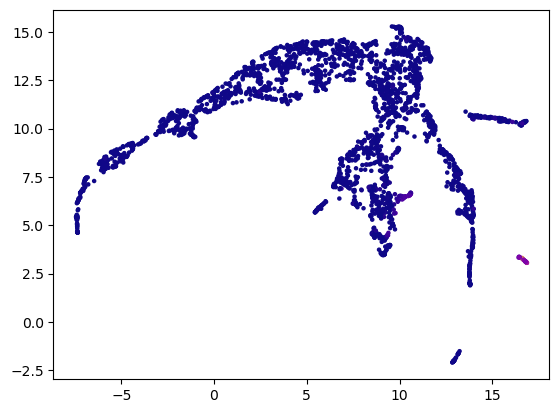

In [198]:
# plot_umap_embeddings(embeddings_redsea, s=3)
plt.scatter(embeddings_redsea[:, 0], embeddings_redsea[:, 1], s=5, c=counts_redsea_umap[:, 4], cmap='plasma')
# plt.scatter(embeddings_redsea[:, 0], embeddings_redsea[:, 1], s=5, c=counts_redsea_umap[:, 3], cmap='virdis')


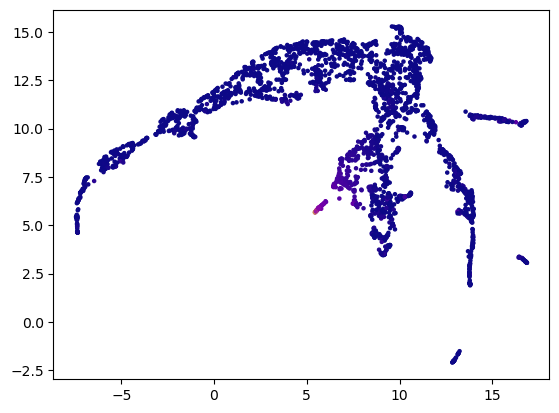

In [202]:
plt.scatter(embeddings_redsea[:, 0], embeddings_redsea[:, 1], s=5, c=counts_redsea_umap[:, 3], cmap='plasma')


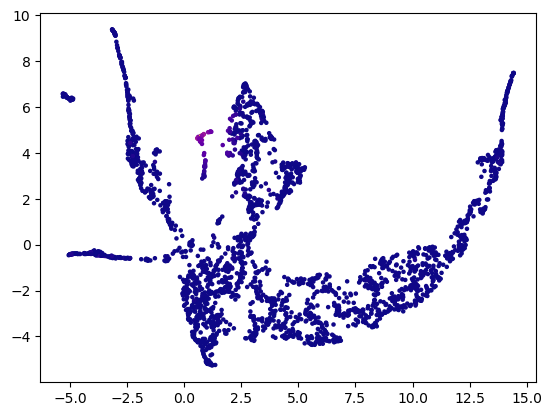

In [199]:
# plot_umap_embeddings(embeddings_ls, s=3)
plt.scatter(embeddings_ls[:, 0], embeddings_ls[:, 1], s=5, c=counts_ls_umap[:, 4], cmap='plasma')


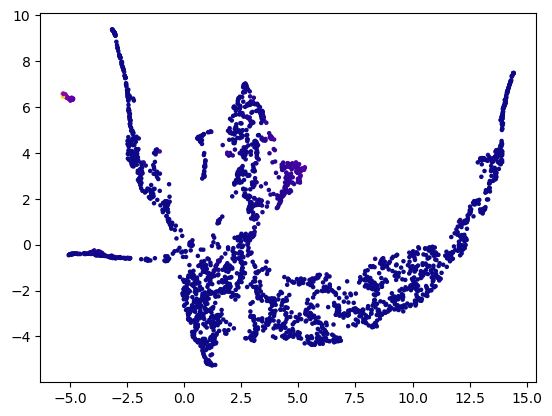

In [203]:
plt.scatter(embeddings_ls[:, 0], embeddings_ls[:, 1], s=5, c=counts_ls_umap[:, 3], cmap='plasma')

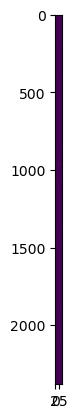

In [57]:
import numpy as np 
import matplotlib.pyplot as plt


plt.imshow(comp_mean, interpolation='none')
plt.show()

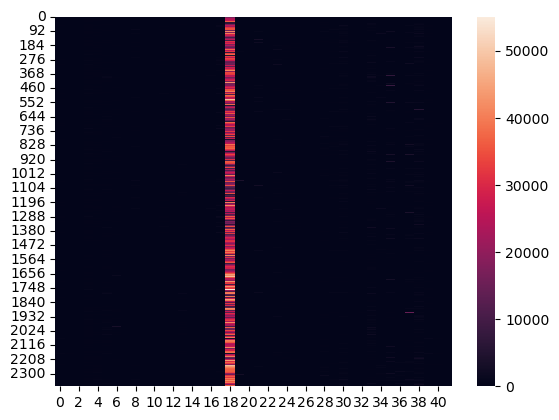

In [64]:
import seaborn as sns
g = sns.heatmap(comp_mean)

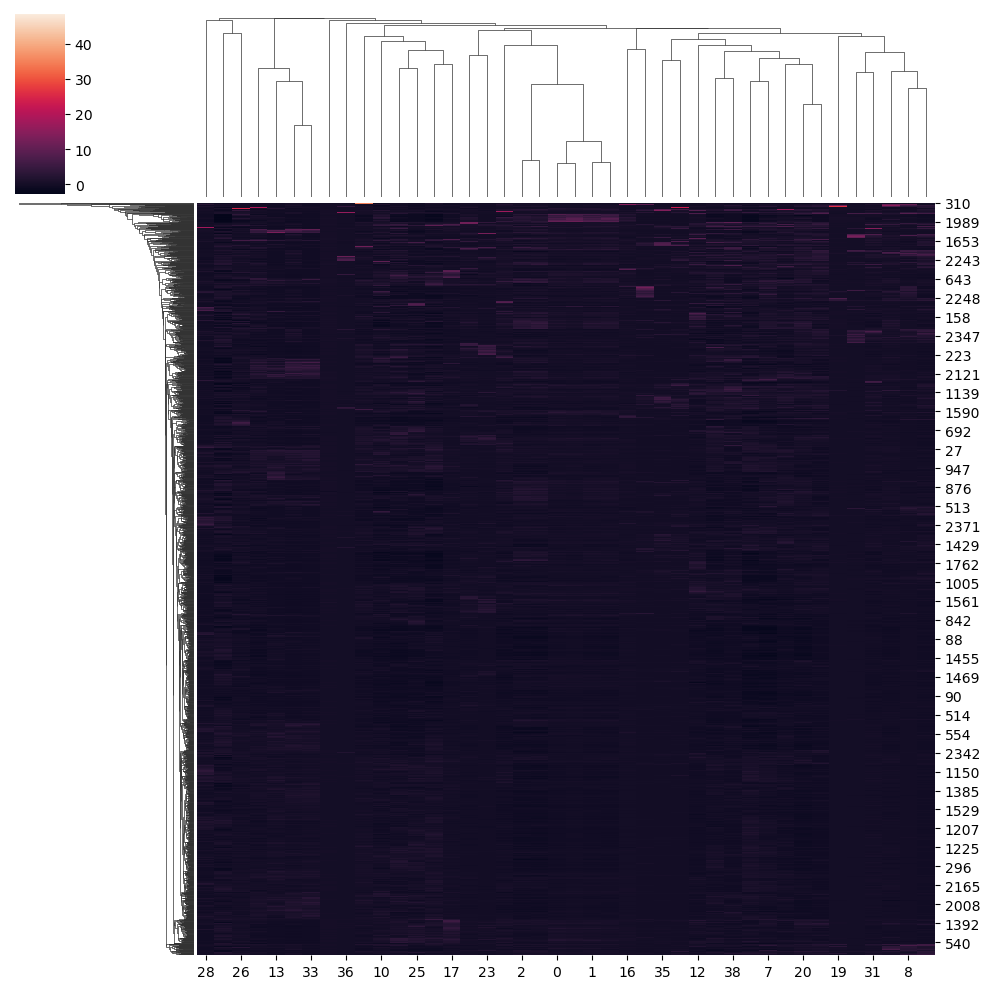

In [63]:
g = sns.clustermap(counts_redsea,
              z_score=1)

In [63]:
comp_mean.shape, counts_redsea.shape

((2382, 42), (2382, 42))

In [64]:
comp_mean

array([[191.35941539,  92.86589407,  41.53741525, ..., 188.99900712,
        146.75789104,  76.61595929],
       [178.3902439 ,  96.18292683,  47.20731707, ..., 183.58536585,
        165.19512195,  91.41463415],
       [175.21212121,  99.03030303,  47.42424242, ..., 180.12121212,
        171.3030303 ,  88.42424242],
       ...,
       [152.03768491,  89.68514448,  42.44322029, ..., 183.60220264,
        154.80296139,  86.30751536],
       [118.56606238,  64.37234141,  32.7518318 , ..., 123.38369343,
        112.47209795,  65.50776725],
       [112.76094885,  74.48682072,  36.53471037, ..., 124.00169677,
        120.31916252,  71.03373388]])

In [51]:
tile.masks['cell_segmentation'].shape

(2048, 2048, 1)

In [18]:
tile_overlap = 200
segmentation_mask = 'cell_segmentation'

pipe = Pipeline([
        CollapseRunsCODEX(z = 0),
        SegmentMIF(
            model = 'mesmer',
            nuclear_channel = nucleus_marker_index,
            cytoplasm_channel = cytoplasm_marker_index,
            image_resolution = 0.5),
        #MembraneMarkerWatershed(
        #    membrane_channel = cytoplasm_marker_index,
        #    marker_segmentation_mask = "nuclear_segmentation",
        #    watershed_line = False,
        #    mask_name = "watershed"),
        CellSegQuantifyMIF(segmentation_mask = segmentation_mask),
        FilterEdgeCells(edge_distance = tile_overlap / 2, slide_shape = slide.shape)
    ])

In [19]:
os.chdir("/n/data2/dfci/cancerimm/wucherpfennig/maxime/projects/CODEX/test/p02_bl_cropped")

In [20]:
! module load cuda/11.2
! module load gcc/6.2.0

In [21]:
tile_size = 2048

print(f"Starting pipeline with tile size {tile_size}, tile overlap {tile_overlap}...")
t1 = time.time()
slide.run(pipe,
          distributed = False,
          tile_size = tile_size,
          tile_stride = tile_size - tile_overlap,
          tile_pad = True,
          normalize = False)

t2 = time.time()
print(f"Finished running pipeline ({str(timedelta(seconds = t2 - t1))})")
print(f"Counts matrix generated: {slide.counts.shape[0]} cells, {slide.counts.shape[1]} markers")

Starting pipeline with tile size 2048, tile overlap 200...


2023-01-18 14:24:26.405939: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /n/app/cuda/11.2/lib64:/n/app/gcc/6.2.0/lib64:/n/app/gcc/6.2.0/lib
2023-01-18 14:24:26.406000: W tensorflow/stream_executor/cuda/cuda_driver.cc:326] failed call to cuInit: UNKNOWN ERROR (303)
2023-01-18 14:24:26.406034: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (compute-a-16-165.o2.rc.hms.harvard.edu): /proc/driver/nvidia/version does not exist
2023-01-18 14:24:26.406475: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.

2023-01-18 14:24:39.182418: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2023-01-18 14:24:39.183552: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 2095185000 Hz


CellSeg count obtained
CellSeg counts saved as anndata


/n/data2/dfci/cancerimm/wucherpfennig/tools/conda_codex_lab/lib/python3.8/site-packages/anndata/_io/h5ad.py:64: FutureWarning: The `force_dense` argument is deprecated. Use `as_dense` instead.
  warn(


...

CellSeg count obtained
CellSeg counts saved as anndata


/n/data2/dfci/cancerimm/wucherpfennig/tools/conda_codex_lab/lib/python3.8/site-packages/anndata/_io/h5ad.py:64: FutureWarning: The `force_dense` argument is deprecated. Use `as_dense` instead.
  warn(


CellSeg count obtained
CellSeg counts saved as anndata


/n/data2/dfci/cancerimm/wucherpfennig/tools/conda_codex_lab/lib/python3.8/site-packages/anndata/_io/h5ad.py:64: FutureWarning: The `force_dense` argument is deprecated. Use `as_dense` instead.
  warn(


CellSeg count obtained
CellSeg counts saved as anndata
Finished running pipeline (1:35:57.373540)
Counts matrix generated: 13750 cells, 42 markers


In [22]:
adata = slide.counts
adata.write(f"{exp_name + '_' + experiment_name}_anndata_cell_cellseg.h5ad")
print(f"Saved AnnData file to: {exp_name + '_' + experiment_name}'_anndata_cell_cellseg.h5ad")

Saved AnnData file to: p02_bl_cropped_cell_cellseg_20220516_Exp030_P02_BL'_anndata_cell_cellseg.h5ad


In [23]:
slide.write(f"{exp_name + '_' + experiment_name}_cell_cellseg.h5path")
print(f"Saved h5path to: {exp_name + '_' +experiment_name}_cell_cellseg.h5path")

Saved h5path to: p02_bl_cropped_cell_cellseg_20220516_Exp030_P02_BL_cell_cellseg.h5path


In [33]:
javabridge.kill_vm()